In [1]:
from qoptcraft import Fock
from qoptcraft.algebra import photon_basis
from qoptcraft.optimization import (
    HeraldedStatePrep, MultiHeraldStatePrep, FeedforwardStatePrep,
    GubarevCost, PiecewiseInfidelityCost,
    MultiHeraldGubarevCost,
    BFGS,
)

import sys, os
sys.path.insert(0, os.path.abspath('..'))
from results_table import examples_table
from perceval_draw import perceval_decomposition

In [2]:
optimizer = BFGS(max_iter=5000, line_search="wolfe")

# Bell

Reference: S. A. Fldzhyan, M. Y. Saygin, and S. P. Kulik, Compact linear optical scheme for Bell state generation, Physical Review Research 3, 043031 (2021)

In [10]:
in_state = Fock(1,1,1,1,0,0)
target_state = Fock(1,0,1,0) + Fock(0,1,0,1)
herald = Fock(1,1)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [ ]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [12]:
PROB_THRESH = 0.073
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,85.0%,7.785%,0.0210,113


# Bell w/ feedforward

Reference: S. A. Fldzhyan, M. Y. Saygin, and S. P. Kulik, Compact linear optical scheme for Bell state generation, Physical Review Research 3, 043031 (2021)

In [13]:
modes = 5
photons = 4
in_state = Fock(1,1,1,0,0)
target_state = Fock(1,0,1,0) + Fock(0,1,0,1)
heralds = [Fock(1), Fock(1)]
problem = FeedforwardStatePrep(in_state, target_state, heralds)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [ ]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [15]:
PROB_THRESH = 0.073
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,90.0%,7.407%,0.0658,72


# Bell (multi-herald)
S. Stanisic, N. Linden, A. Montanaro, and P. S. Turner, Generating entanglement with linear optics, Physical Review A 96, 043861 (2017)

In [16]:
in_state = Fock(1,1,1,1,0,0,0,0)
target_states = [
    Fock(1,0,1,0) + Fock(0,1,0,1),
    Fock(1,0,1,0) - Fock(0,1,0,1),
    Fock(1,0,0,1) + Fock(0,1,1,0),
    Fock(1,0,0,1) - Fock(0,1,1,0),
    Fock(1,1,0,0) + Fock(0,0,1,1),
    Fock(1,1,0,0) - Fock(0,0,1,1),
]
heralds = list(photon_basis(4, 2))
problem = MultiHeraldStatePrep(in_state, target_states, heralds)
cost_fun = MultiHeraldGubarevCost(problem, alpha=1, beta=5)

In [ ]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [18]:
PROB_THRESH = 6 / 32
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,6.0%,18.750%,0.0909,70


# NOON $\ket{40} + \ket{04}$

In [19]:
in_state = Fock(1,1,1,1)
target_state = Fock(4,0) + Fock(0,4)
herald = Fock(0,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [ ]:
N_RUNS = 1000
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [21]:
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,1000,98.7%,18.750%,0.0070,32


# NOON $\ket{40} + \ket{04}$
H. Lee, P. Kok, N. J. Cerf, and J. P. Dowling, Linear optics and projective measurements alone suffice to create large-photon-number path entanglement, Phys. Rev. A 65, 030101(R) (2002).

In [22]:
in_state = Fock(2,2,1,1)
target_state = Fock(4,0) + Fock(0,4)
herald = Fock(1,1)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [24]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [25]:
PROB_THRESH = 0.0469
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,58.0%,16.530%,0.0208,139


# NOON $\ket{50} + \ket{05}$

VanMeter et al.

In [26]:
in_state = Fock(2,2,2,0)
target_state = Fock(5,0) + Fock(0,5)
herald = Fock(1,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [ ]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [28]:
PROB_THRESH = 0.056
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,61.0%,5.643%,0.0140,64


# NOON $\ket{50} + \ket{05}$ alternative

Improvement over VanMeter et al.

In [3]:
in_state = Fock(2,2,1,1)
target_state = Fock(5,0) + Fock(0,5)
herald = Fock(1,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [4]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

/Users/KaerMorhen/Documents/Code projects/qoptcraft-state/qoptcraft/optimization/optimizers/riemannian_optimizer.py:295: RuntimeWarning: Wolfe line search failed to find a conforming step size; 
  step_size, new_cost, new_point, new_grad = self.line_search(
/Users/KaerMorhen/Documents/Code projects/qoptcraft-state/qoptcraft/optimization/optimizers/riemannian_optimizer.py:79: RuntimeWarning: Wolfe line search failed; falling back to Armijo for this step.
  step_size, new_cost, point, grad = self._step(cost, point, grad)


In [5]:
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,21.0%,9.169%,0.0097,46


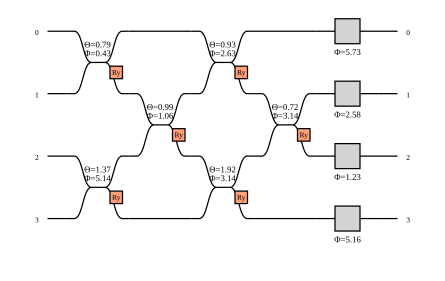

In [7]:
converged = [r for r in all_results["Riemannian optimizer"] if 1 - r.fidelity < 1e-7]
best_point = max(converged, key=lambda r: r.prob).point
circuit = perceval_decomposition(best_point, save_path="noon_50_05_circuit.svg")

# NOON $\ket{60} + \ket{06}$

In [ ]:
in_state = Fock(1,1,1,1,1,1)
target_state = Fock(6,0) + Fock(0,6)
herald = Fock(0,0,0,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1, beta=4)

In [ ]:
N_RUNS = 10000
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [ ]:
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,10000,96.7%,3.086%,0.0087,32


# NOON $\ket{80} + \ket{08}$

*Linear optical scheme for producing polarization-entangled NOON states* by Su-Yong Lee, Tomasz Paterek, Hee Su Park, Hyunchul Nha. They report a probability of $\approx 0.5\%$

In [ ]:
in_state = Fock(1,1,1,1,1,1,1,1)
target_state = Fock(8,0) + Fock(0,8)
herald = Fock(0,0,0,0,0,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1, beta=4)

In [ ]:
N_RUNS = 10000
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [ ]:
examples_table(all_results, problem, time_format=".4f")

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,10000,84.6%,0.481%,0.0488,71


# GHZ 10 modes
F. V. Gubarev, I. V. Dyakonov, M. Y. Saygin, G. I. Struchalin, S. S. Straupe, and S. P. Kulik, Improved Heralded Schemes to Generate Entangled States From Single Photons, Physical Review A 102, 012604 (2020).

In [7]:
in_state = Fock(1,1,1,1,1,1) * Fock(0,0,0,0)
target_state = Fock(0,1,0,1,0,1) + Fock(1,0,1,0,1,0)
herald = Fock(1,1,1,0)
problem = HeraldedStatePrep(in_state, target_state, herald)
cost_fun = GubarevCost(problem, alpha=1e-3, beta=4)

In [ ]:
N_RUNS = 100
all_results = {
    "Riemannian optimizer": [
        optimizer.minimize(cost_fun, cost_fun.manifold.random_point(), verbose=False)
        for _ in range(N_RUNS)
    ]
}

In [9]:
PROB_THRESH = 0.0092
examples_table(all_results, problem)

,Runs,Converged (%),Best prob (%),Mean time (s),Mean iters
Optimizer,,,,,
Riemannian optimizer,100,10.0%,0.926%,0.619,658
